In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [10]:
df = pd.read_csv('../data/processed/student_performance_datasetv2.csv')
df.head()

,student_id,attendance_percentage,quiz_score_avg,assignment_score_avg,midterm_score,historical_gpa,study_hours_per_week,participation_score,subject_difficulty_score,semester_number,final_score,pass_fail
0,510845f3-fec3-423e-84ba-12422f4f8058,78.11,55.80,54.96,59.20,2.31,15.7,75.80,0.374,6,51.65,0
1,85fe2085-7fc6-41a7-9819-9062e3f12102,66.63,69.04,64.40,69.31,3.19,23.5,83.34,0.505,2,69.10,1
2,a1e6e199-b45e-408a-b633-2cc2656dab41,98.21,60.37,57.75,71.17,2.69,15.0,71.54,0.918,4,65.41,1
3,ed75ac0f-5371-4900-b7fa-b59e8978a2ec,79.88,59.76,50.62,44.16,2.34,26.4,72.74,0.613,4,60.38,1
4,2bcfaf42-2ff8-45b6-9975-e8f668e78fe8,66.58,45.49,57.01,49.74,2.12,20.6,72.96,0.227,7,49.10,0


In [11]:
df.shape

(5000, 12)

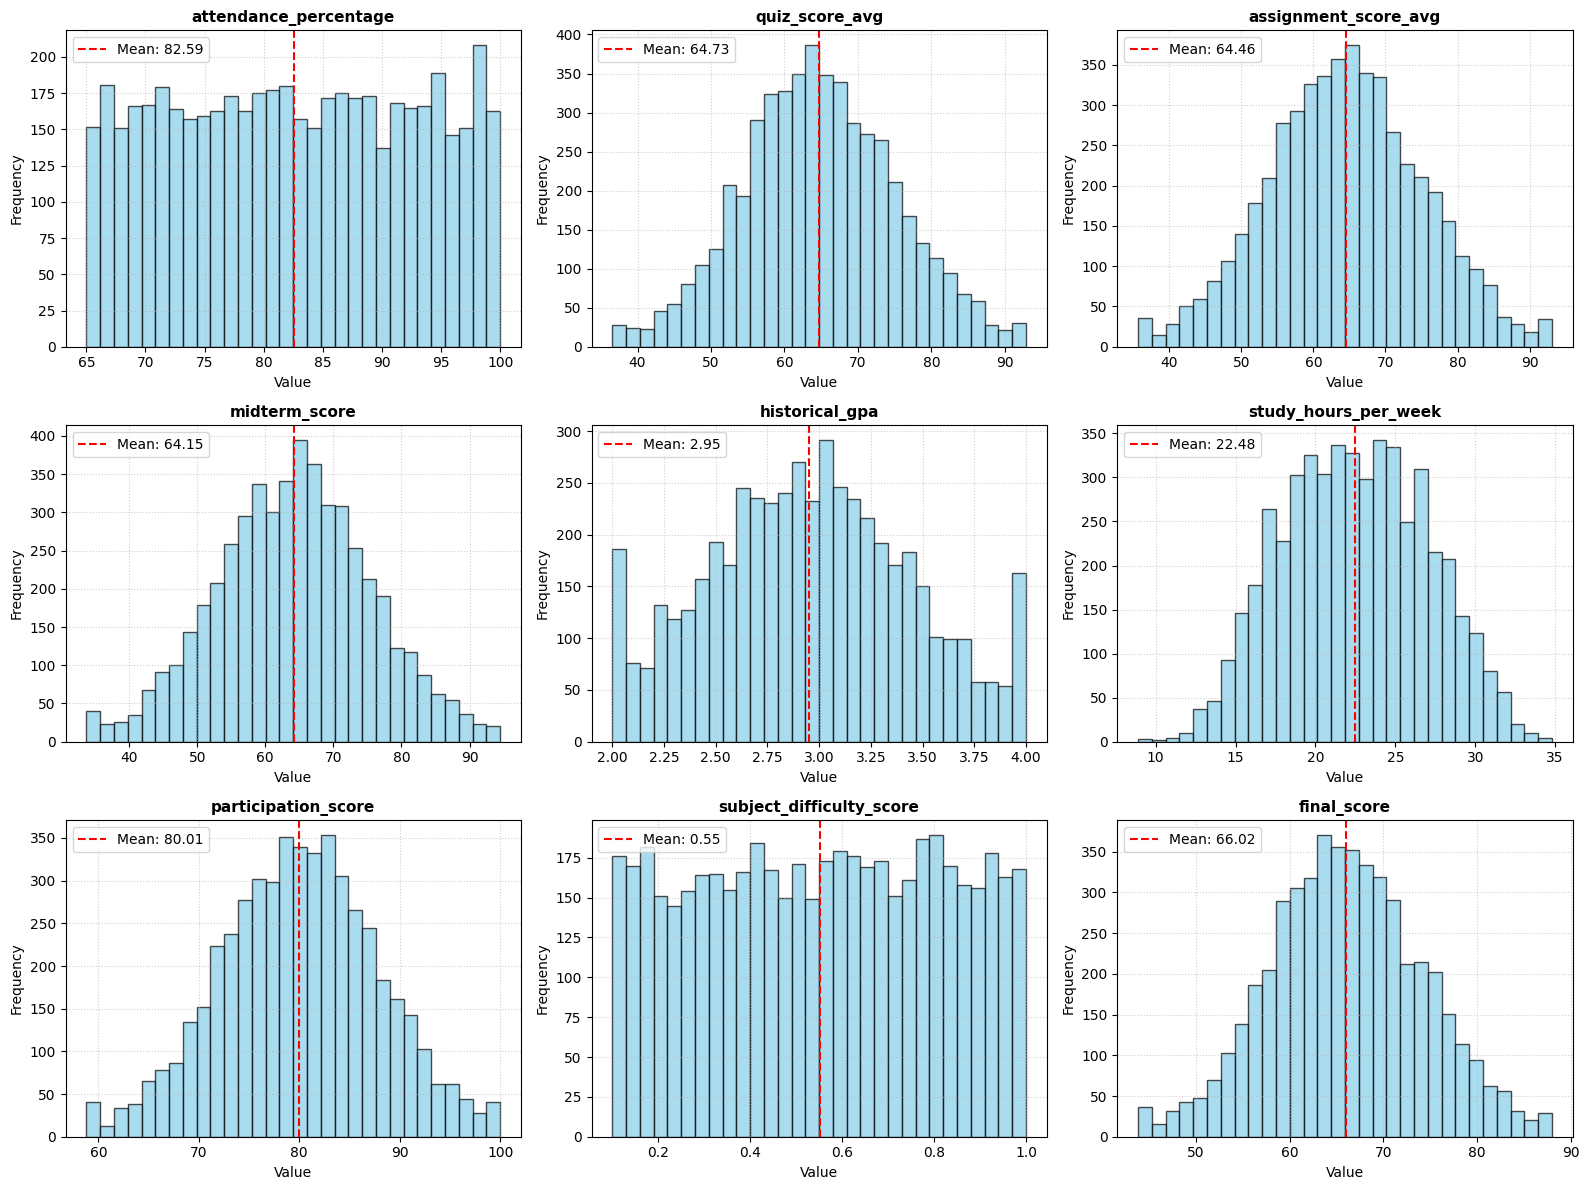

In [14]:
#histogram to see skewness of the data


# List of the 9 columns to plot
cols_to_plot = [
    "attendance_percentage", 
    "quiz_score_avg", 
    "assignment_score_avg", 
    "midterm_score", 
    "historical_gpa", 
    "study_hours_per_week", 
    "participation_score", 
    "subject_difficulty_score", 
    "final_score"
]

# Set up the 3x3 subplot grid layout
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()  # Flatten the 2D grid into a 1D array for easier iteration

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # Plot histogram with 30 bins
    ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Calculate and plot the mean vertical line
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    
    # Labeling and formatting
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)

# Automatically adjust padding to ensure no labels overlap or truncate
plt.tight_layout()

# Save the complete figure
plt.savefig("../eda/distributions.png", dpi=150)

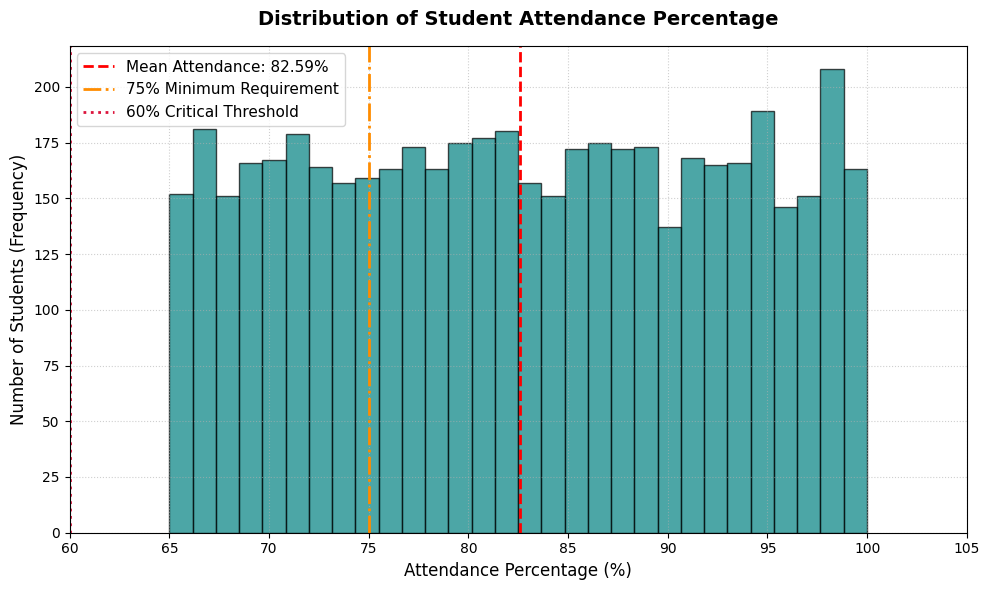

In [15]:
# Create a separate, larger figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the attendance histogram with 30 bins
ax.hist(df['attendance_percentage'], bins=30, color='teal', edgecolor='black', alpha=0.7)

# Calculate the mean
mean_attendance = df['attendance_percentage'].mean()

# Add the vertical milestone and threshold lines
ax.axvline(mean_attendance, color='red', linestyle='dashed', linewidth=2, 
           label=f'Mean Attendance: {mean_attendance:.2f}%')

ax.axvline(75, color='darkorange', linestyle='-.', linewidth=2, 
           label='75% Minimum Requirement')

ax.axvline(60, color='crimson', linestyle=':', linewidth=2, 
           label='60% Critical Threshold')

# Labeling and Formatting
ax.set_title('Distribution of Student Attendance Percentage', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attendance Percentage (%)', fontsize=12)
ax.set_ylabel('Number of Students (Frequency)', fontsize=12)
ax.set_xlim(df['attendance_percentage'].min() - 5, 105) # Keep a clean window scale

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

# Apply tight layout and save the specific image
plt.tight_layout()
plt.savefig("../eda/attendance_distribution.png", dpi=150)

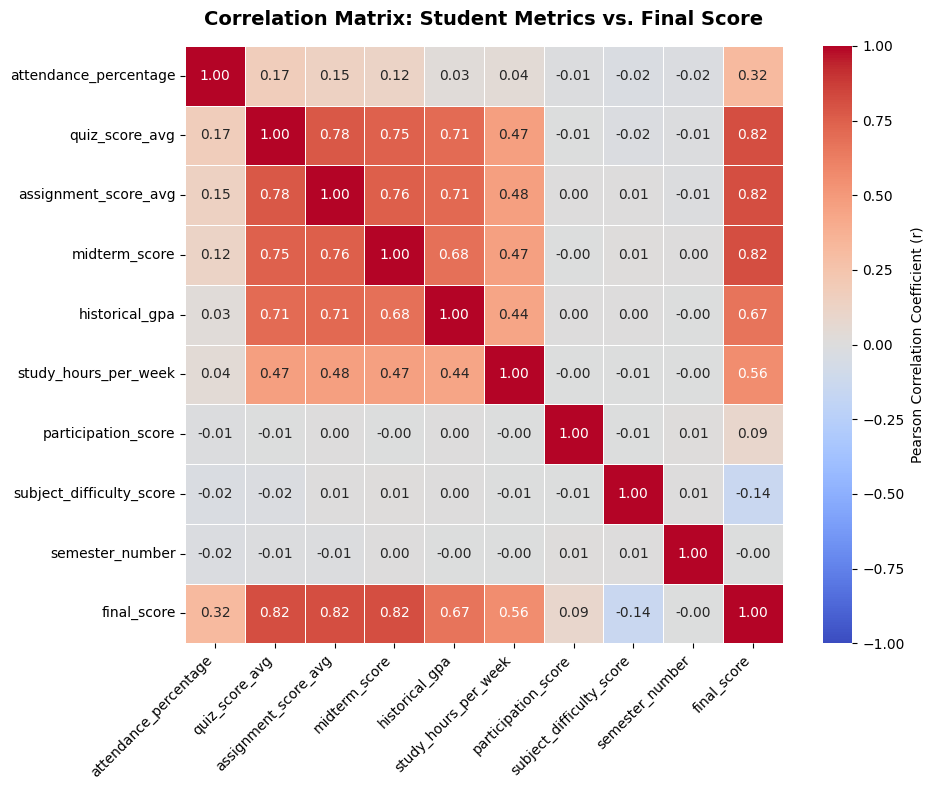

In [17]:
#correlarion heatmap
# Define all numerical feature columns plus the target final_score
# Excluded: student_id (string/UUID) and pass_fail (binary classification target)
correlation_cols = [
    "attendance_percentage", 
    "quiz_score_avg", 
    "assignment_score_avg", 
    "midterm_score", 
    "historical_gpa", 
    "study_hours_per_week", 
    "participation_score", 
    "subject_difficulty_score", 
    "semester_number",
    "final_score"
]

# Calculate the Pearson correlation matrix
corr_matrix = df[correlation_cols].corr()

# Set up the plotting environment
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,                 # Show the actual r values in the cells
    fmt=".2f",                  # Round values to two decimal places
    cmap="coolwarm",            # Blue for negative, Red for positive correlation
    vmin=-1.0, vmax=1.0,        # Standard correlation scale boundaries
    linewidths=0.5,             # Add crisp lines between cells
    square=True,                # Force cells to be perfect squares
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"},
    ax=ax
)

# Formatting adjustments
ax.set_title("Correlation Matrix: Student Metrics vs. Final Score", fontsize=14, fontweight='bold', pad=15)

# Rotate labels slightly to ensure clean legibility
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Save the matrix layout safely
plt.tight_layout()
plt.savefig("../eda/correlation_matrix.png", dpi=150)

In [ ]:
#eature against final_score sorted from highest to lowest
corr_matrix = df[correlation_cols].corr()

# 2. Extract correlation with final_score, drop final_score itself, and sort descending
final_score_corr = corr_matrix['final_score'].drop('final_score').sort_values(ascending=False)

print("--- Feature Correlation against final_score (Sorted) ---")
for feature, r_val in final_score_corr.items():
    print(f"{feature: <25}: r = {r_val:.4f}")

print("\n--- Target Value Confirmation ---")

# Extract specific values
r_midterm = final_score_corr['midterm_score']
r_attendance = final_score_corr['attendance_percentage']

# Confirm Midterm (Expected: 0.75 - 0.85)
if 0.75 <= r_midterm <= 0.85:
    print(f"✅ PASS: midterm_score correlation (r = {r_midterm:.4f}) matches the expected r ≈ 0.75–0.85 range.")
else:
    print(f"❌ FAIL: midterm_score correlation (r = {r_midterm:.4f}) falls outside the expected r ≈ 0.75–0.85 range.")

# Confirm Attendance (Expected: 0.55 - 0.70)
if 0.55 <= r_attendance <= 0.70:
    print(f"✅ PASS: attendance_percentage correlation (r = {r_attendance:.4f}) matches the expected r ≈ 0.55–0.70 range.")
else:
    print(f"❌ FAIL: attendance_percentage correlation (r = {r_attendance:.4f}) falls outside the expected r ≈ 0.55–0.70 range.")

--- Feature Correlation against final_score (Sorted) ---
midterm_score            : r = 0.8187
assignment_score_avg     : r = 0.8177
quiz_score_avg           : r = 0.8163
historical_gpa           : r = 0.6718
study_hours_per_week     : r = 0.5581
attendance_percentage    : r = 0.3175
participation_score      : r = 0.0909
semester_number          : r = -0.0048
subject_difficulty_score : r = -0.1414

--- Target Value Confirmation ---
✅ PASS: midterm_score correlation (r = 0.8187) matches the expected r ≈ 0.75–0.85 range.
❌ FAIL: attendance_percentage correlation (r = 0.3175) falls outside the expected r ≈ 0.55–0.70 range.


--- Class Balance Statistics ---
Fail (0): 1166 students (23.32%)
Pass (1): 3834 students (76.68%)
Total   : 5000 students


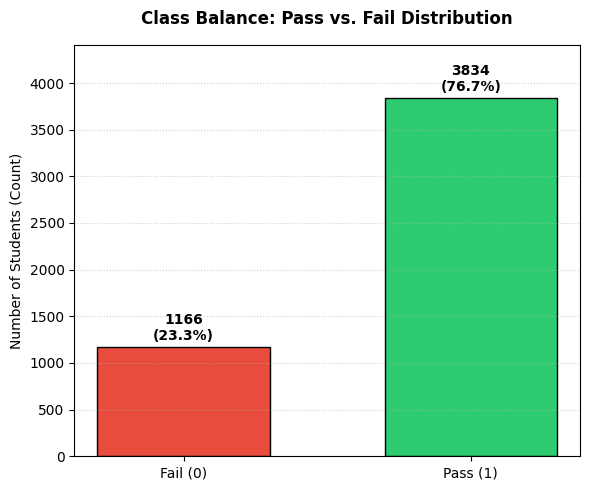

In [20]:
#Pass/Fail Class Balance Check
# 1. Calculate counts and percentages
counts = df['pass_fail'].value_counts()
# Ensure both 0 and 1 are represented even if one is missing experimentally
fail_count = counts.get(0, 0)
pass_count = counts.get(1, 0)
total = len(df)

fail_pct = (fail_count / total) * 100
pass_pct = (pass_count / total) * 100

# 2. Print exact statistics to the console
print("--- Class Balance Statistics ---")
print(f"Fail (0): {fail_count} students ({fail_pct:.2f}%)")
print(f"Pass (1): {pass_count} students ({pass_pct:.2f}%)")
print(f"Total   : {total} students")

# 3. Plot the simple bar chart
fig, ax = plt.subplots(figsize=(6, 5))

categories = ['Fail (0)', 'Pass (1)']
values = [fail_count, pass_count]
colors = ['#e74c3c', '#2ecc71']  # Crisp red for fail, green for pass

bars = ax.bar(categories, values, color=colors, edgecolor='black', width=0.6)

# Add exact count and percentage text labels on top of each bar
for bar, pct in zip(bars, [fail_pct, pass_pct]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + (total * 0.01),  # Small offset above bar
        f'{int(height)}\n({pct:.1f}%)', 
        ha='center', 
        va='bottom', 
        fontweight='bold'
    )

# Formatting and labeling
ax.set_title('Class Balance: Pass vs. Fail Distribution', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Number of Students (Count)', fontsize=10)
ax.set_ylim(0, max(values) * 1.15)  # Leave room for the text labels on top
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# Save the metric visual layout
plt.tight_layout()
plt.savefig("../eda/class_balance.png", dpi=150)

C:\Users\panth\AppData\Local\Temp\ipykernel_23872\1167219241.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fail (0)', 'Pass (1)'], fontsize=10)
C:\Users\panth\AppData\Local\Temp\ipykernel_23872\1167219241.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fail (0)', 'Pass (1)'], fontsize=10)
C:\Users\panth\AppData\Local\Temp\ipykernel_23872\1167219241.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fail (0)', 'Pass (1)'], fontsize=10)
C:\Users\panth\AppData\Local\Temp\ipykernel_23872\1167219241.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fail (0)', 'P

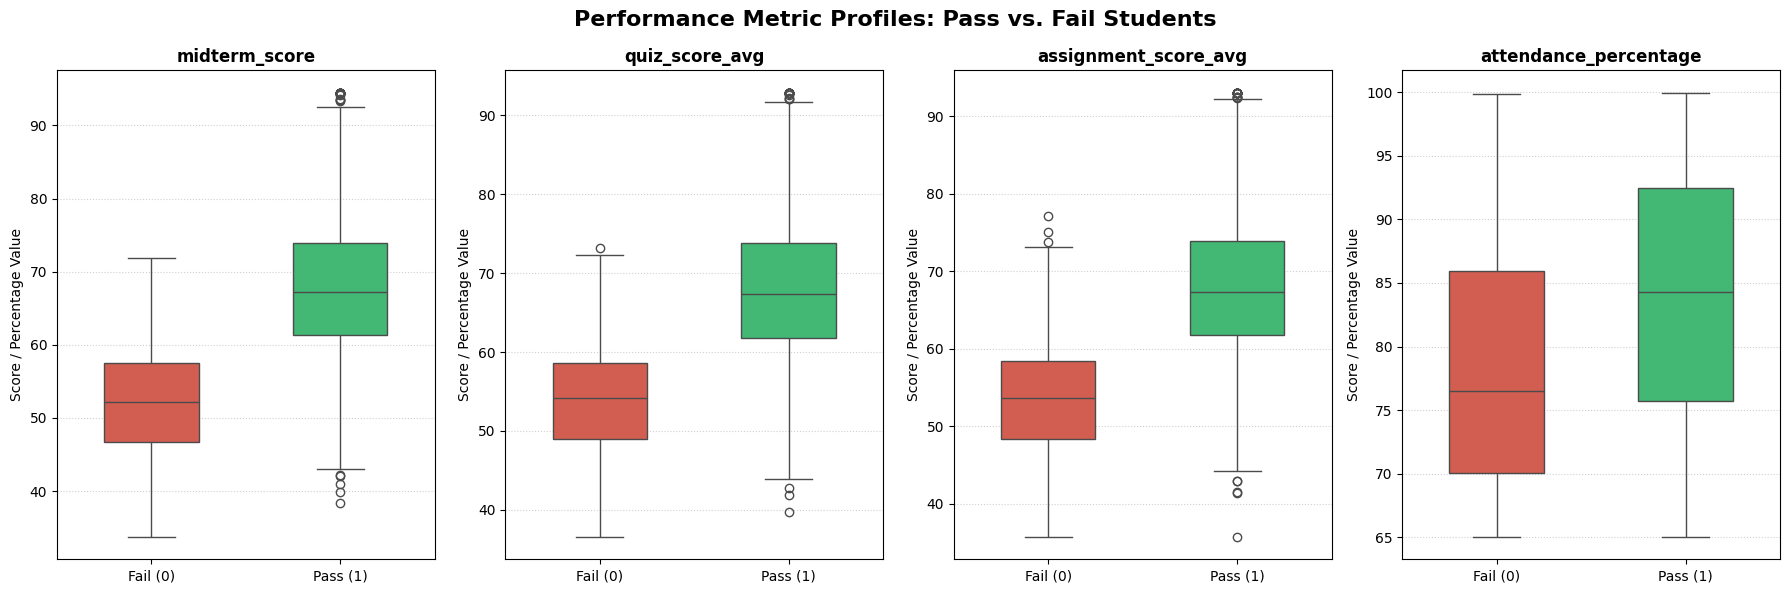

In [21]:
compare_cols = ["midterm_score", "quiz_score_avg", "assignment_score_avg", "attendance_percentage"]

# Set up a 1 row x 4 columns horizontal layout for direct comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)

# Define custom palette: Crimson for Fail (0), Emerald Green for Pass (1)
custom_palette = {0: '#e74c3c', 1: '#2ecc71'}

for i, col in enumerate(compare_cols):
    ax = axes[i]
    
    # Create the boxplot split by pass_fail status
    sns.boxplot(
        data=df, 
        x='pass_fail', 
        y=col, 
        hue='pass_fail',
        palette=custom_palette, 
        width=0.5,
        legend=False,  # Title/axis labels make the breakdown obvious, legend is redundant
        ax=ax
    )
    
    # Labeling and styling tweaks
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Fail (0)', 'Pass (1)'], fontsize=10)
    ax.set_xlabel('')  # Clear redundant 'pass_fail' x-axis label
    ax.set_ylabel('Score / Percentage Value', fontsize=10)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# Main layout title decoration
plt.suptitle("Performance Metric Profiles: Pass vs. Fail Students", fontsize=16, fontweight='bold', y=0.98)

# Adjust padding and save 
plt.tight_layout()
plt.savefig("../eda/pass_fail_comparison.png", dpi=150)

In [ ]:
# Generate the summary statistics dataframe (includes count, mean, std, min, 25%, 50%, 75%, max)
summary_df = df.describe()

# Export it to the requested CSV path
summary_df.to_csv("../eda/summary_statistics.csv", index=True)